# 🍷 Wine Classification Model Training

## 📌 Overview
This project focuses on building a Machine Learning model to classify wines into different categories based on their chemical properties.

We use the Wine dataset from `sklearn`, which contains 13 features such as alcohol content, acidity, and color intensity.

## 🔍 Key Features
- Multi-model comparison  
- Cross-validation for accuracy  
- SVM optimization  
- Feature scaling  
- Model evaluation  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import model_selection
from sklearn.datasets import load_wine
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

## 📊 Dataset
- Built-in Wine Dataset (Scikit-learn)  
- 13 input features  
- 3 output classes  

In [2]:
wine = load_wine()
X = wine.data
Y = wine.target

seed = 7

scaler = StandardScaler()
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=7)

scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [3]:
models = []
models.append(('LR', LogisticRegression(max_iter=5000)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))


In [4]:
results = []
names = []
scoring = 'accuracy'

In [5]:
for name, model in models:
    kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state=seed)
    cv_results = model_selection.cross_val_score(model, X, Y, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    print(f"{name}: {cv_results.mean():.4f} ({cv_results.std():.4f})")

C:\Users\abhin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LR: 0.9605 (0.0259)
LDA: 0.9833 (0.0255)
KNN: 0.7124 (0.1073)
CART: 0.8876 (0.0556)
NB: 0.9771 (0.0280)
SVM: 0.6912 (0.0825)


# 📈 Model Comparison

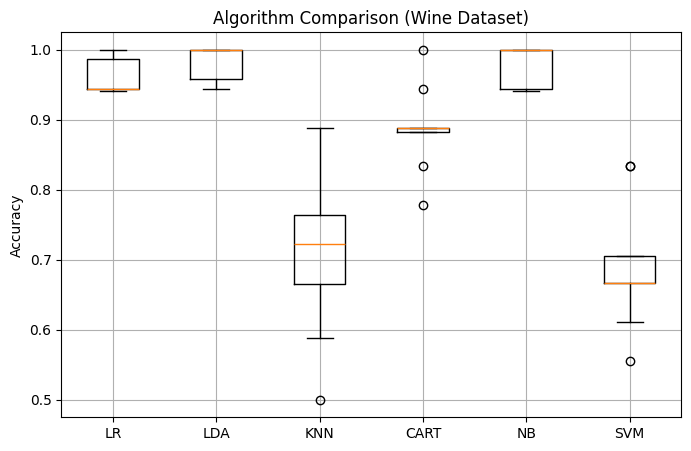

In [6]:
plt.figure(figsize=(8,5))
plt.title('Algorithm Comparison (Wine Dataset)')
plt.boxplot(results)
plt.xticks(range(1, len(names)+1), names)
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [7]:
best_index = max(range(len(results)), key=lambda i: results[i].mean())
print("\nBest Model:", names[best_index])


Best Model: LDA


In [8]:
best_model = SVC(kernel='rbf', C=1)
best_model.fit(X_train, Y_train)
preds = best_model.predict(X_test)

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

preds = best_model.predict(X)

print(confusion_matrix(Y, preds))
print(classification_report(Y, preds))

[[ 0 59  0]
 [ 0 71  0]
 [ 0 48  0]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        59
           1       0.40      1.00      0.57        71
           2       0.00      0.00      0.00        48

    accuracy                           0.40       178
   macro avg       0.13      0.33      0.19       178
weighted avg       0.16      0.40      0.23       178



C:\Users\abhin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\abhin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\abhin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X, Y)

print("Best SVM Parameters:", grid.best_params_)
print("Best SVM Score:", grid.best_score_)

Best SVM Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best SVM Score: 0.961111111111111


## 📈 Results
- Multiple models were evaluated  
- Best model selected based on accuracy  
- SVM performance improved after tuning  

In [13]:
import joblib
joblib.dump(best_model, "wine_model.pkl") 

['wine_model.pkl']

In [14]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

## 📌 Conclusion
This project demonstrates the use of machine learning algorithms for classification tasks and highlights the importance of model comparison, tuning, and evaluation in building effective predictive systems.